# FinSmart — Spending Prediction dengan LSTM
**Coding Camp 2026 | CC26-PSU407 | Muhammad Syaiful**

---

Notebook ini membangun model **LSTM (Long Short-Term Memory)** untuk memprediksi total pengeluaran pengguna pada bulan berikutnya berdasarkan histori pengeluaran bulanan.

| No | Bagian | Section |
|----|--------|---------|
| 1 | Install dan Import Library | Section 1 |
| 2 | Load dan Eksplorasi Dataset | Section 2 |
| 3 | Preprocessing dan Feature Engineering | Section 3 |
| 4 | Persiapan Data LSTM (Sequence) | Section 4 |
| 5 | Arsitektur Model LSTM | Section 5 |
| 6 | Training Model | Section 6 |
| 7 | Evaluasi Model | Section 7 |
| 8 | Visualisasi Hasil Prediksi | Section 8 |
| 9 | Kode Inference | Section 9 |
| 10 | Simpan Model dan Artifacts | Section 10 |
| 11 | Uji Inference | Section 11 |
| 12 | Ringkasan | Section 12 |


## 1. Install dan Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import pickle
import warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print('Semua library berhasil diimport')

TensorFlow : 2.20.0
NumPy      : 2.0.2
Semua library berhasil diimport


## 2. Load dan Eksplorasi Dataset

In [2]:
df = pd.read_csv('dataset_spending_prediction.csv')

print(f'Shape dataset : {df.shape}')
print(f'Jumlah user   : {df["user_id"].nunique()}')
print(f'Periode       : {df["month"].min()} - {df["month"].max()} (12 bulan)')
print(f'Kolom         : {df.columns.tolist()}')
print()
print('5 baris pertama:')
df.head()

Shape dataset : (2400, 17)
Jumlah user   : 200
Periode       : 1 - 12 (12 bulan)
Kolom         : ['user_id', 'year', 'month', 'month_name', 'income', 'total_spending', 'savings', 'tipe_pengguna', 'Food & Dining', 'Transportation', 'Shopping', 'Groceries', 'Bills & Utilities', 'Entertainment', 'Health', 'Education', 'Others']

5 baris pertama:


,user_id,year,month,month_name,income,total_spending,savings,tipe_pengguna,Food & Dining,Transportation,Shopping,Groceries,Bills & Utilities,Entertainment,Health,Education,Others
0,USER_001,2025,1,Jan,9655568,4998608,4656960,hemat,743619,1209940,370674,389811,20803,1165783,424732,318745,354500
1,USER_001,2025,2,Feb,9479227,5231909,4247318,hemat,735367,377463,467129,428024,465906,922595,1335002,158378,342046
2,USER_001,2025,3,Mar,9687857,5177276,4510581,hemat,888519,599378,480611,412900,360008,1085732,669872,384456,295801
3,USER_001,2025,4,Apr,9059718,5161660,3898058,hemat,553270,586008,406457,311914,784258,806606,816796,740593,155756
4,USER_001,2025,5,May,9569302,5216938,4352364,hemat,898864,131543,1056861,331132,119652,436573,364175,744880,1133257


In [3]:
print('Statistik total_spending:')
print(df['total_spending'].describe())
print()
print('Distribusi tipe pengguna:')
print(df['tipe_pengguna'].value_counts())
print()
print('Missing values:', df.isnull().sum().sum())

Statistik total_spending:
count    2.400000e+03
mean     6.947580e+06
std      3.459614e+06
min      1.392226e+06
25%      4.170028e+06
50%      6.479820e+06
75%      8.995487e+06
max      2.353646e+07
Name: total_spending, dtype: float64

Distribusi tipe pengguna:
tipe_pengguna
normal    984
boros     732
hemat     684
Name: count, dtype: int64

Missing values: 0


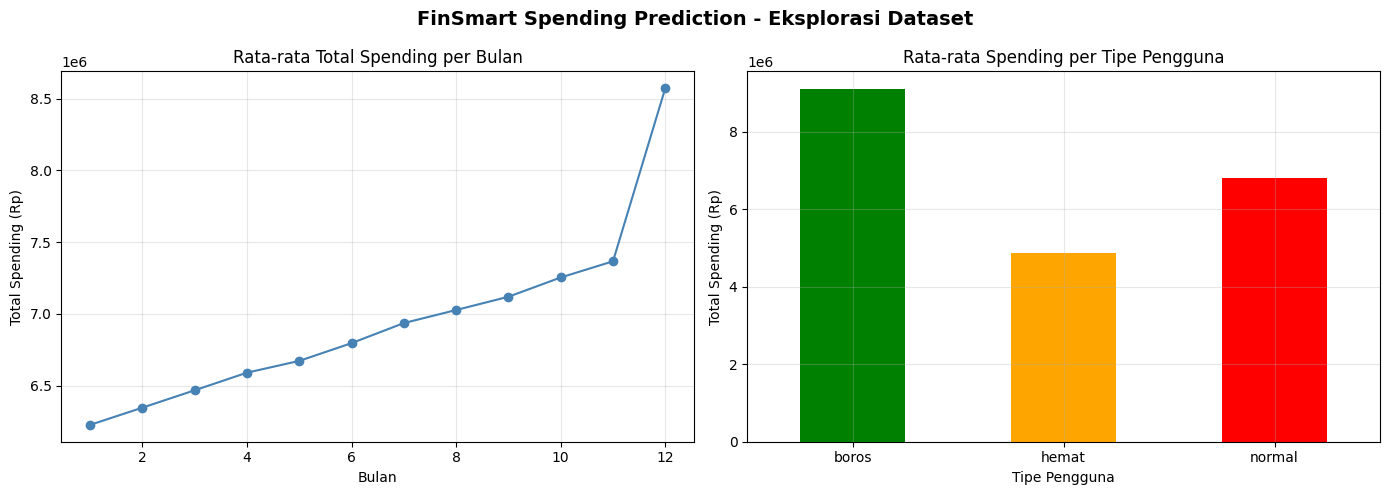

Grafik disimpan: spending_exploration.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FinSmart Spending Prediction - Eksplorasi Dataset', fontsize=14, fontweight='bold')

df.groupby('month')['total_spending'].mean().plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Rata-rata Total Spending per Bulan')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Total Spending (Rp)')
axes[0].grid(True, alpha=0.3)

df.groupby('tipe_pengguna')['total_spending'].mean().plot(kind='bar', ax=axes[1], color=['green','orange','red'])
axes[1].set_title('Rata-rata Spending per Tipe Pengguna')
axes[1].set_xlabel('Tipe Pengguna')
axes[1].set_ylabel('Total Spending (Rp)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('spending_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: spending_exploration.png')

## 3. Preprocessing dan Feature Engineering

In [5]:
FEATURES = [
    'income',
    'total_spending',
    'savings',
    'Food & Dining',
    'Transportation',
    'Shopping',
    'Groceries',
    'Bills & Utilities',
    'Entertainment',
    'Health',
    'Education',
    'Others'
]
TARGET = 'total_spending'

scaler_lstm = MinMaxScaler()
df_scaled = df.copy()
df_scaled[FEATURES] = scaler_lstm.fit_transform(df[FEATURES])

print(f'Fitur yang digunakan : {len(FEATURES)} fitur')
print(f'Target               : {TARGET}')
print(f'Setelah scaling - min: {df_scaled[FEATURES].min().min():.4f}, max: {df_scaled[FEATURES].max().max():.4f}')

Fitur yang digunakan : 12 fitur
Target               : total_spending
Setelah scaling - min: 0.0000, max: 1.0000


## 4. Persiapan Data LSTM (Sequence)

LSTM membutuhkan data dalam format sequence (urutan waktu). Untuk setiap user, dibuat sequence dengan window size N bulan untuk memprediksi bulan berikutnya.


In [6]:
SEQUENCE_LENGTH = 3

def create_sequences(df_user, features, target, seq_len):
    X, y = [], []
    values  = df_user.sort_values('month')[features].values
    targets = df_user.sort_values('month')[target].values
    for i in range(len(values) - seq_len):
        X.append(values[i:i + seq_len])
        y.append(targets[i + seq_len])
    return np.array(X), np.array(y)

X_all, y_all = [], []
for user_id in df_scaled['user_id'].unique():
    df_user = df_scaled[df_scaled['user_id'] == user_id]
    X_user, y_user = create_sequences(df_user, FEATURES, TARGET, SEQUENCE_LENGTH)
    if len(X_user) > 0:
        X_all.append(X_user)
        y_all.append(y_user)

X_all = np.concatenate(X_all, axis=0)
y_all = np.concatenate(y_all, axis=0)

print(f'Shape X (sequences) : {X_all.shape}')
print(f'Shape y (target)    : {y_all.shape}')
print(f'Sequence length     : {SEQUENCE_LENGTH} bulan')
print(f'Jumlah fitur        : {len(FEATURES)}')
print(f'Total sequences     : {len(X_all)}')

Shape X (sequences) : (1800, 3, 12)
Shape y (target)    : (1800,)
Sequence length     : 3 bulan
Jumlah fitur        : 12
Total sequences     : 1800


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Train : {X_train.shape[0]} sequences')
print(f'Val   : {X_val.shape[0]} sequences')
print(f'Test  : {X_test.shape[0]} sequences')

Train : 1260 sequences
Val   : 270 sequences
Test  : 270 sequences


## 5. Arsitektur Model LSTM

Menggunakan TensorFlow Functional API dengan arsitektur LSTM bertingkat.


In [8]:
def build_lstm_model(seq_len, n_features):
    inputs = keras.Input(shape=(seq_len, n_features), name='input_sequence')

    x = layers.LSTM(128, return_sequences=True, name='lstm_1')(inputs)
    x = layers.Dropout(0.2, name='dropout_1')(x)

    x = layers.LSTM(64, return_sequences=False, name='lstm_2')(x)
    x = layers.Dropout(0.2, name='dropout_2')(x)

    x = layers.Dense(32, activation='relu', name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)

    outputs = layers.Dense(1, name='output_spending')(x)

    model = Model(inputs=inputs, outputs=outputs, name='FinSmart_LSTM')
    return model

lstm_model = build_lstm_model(
    seq_len=SEQUENCE_LENGTH,
    n_features=len(FEATURES)
)

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()

Model: "FinSmart_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)     │ (None, 3, 12)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 3, 128)         │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_spending (Dense)         │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,841 (483.75 KB)

 Trainable params: 123,777 (483.50 KB)

 Non-trainable params: 64 (256.00 B)

## 6. Training Model

In [9]:
class FinSmartLSTMCallback(Callback):
    def __init__(self, log_path='training_log_lstm.json'):
        super().__init__()
        self.log_path = log_path
        self.training_log = []

    def on_train_begin(self, logs=None):
        print('=' * 55)
        print('Training FinSmart LSTM Spending Prediction')
        print('=' * 55)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        entry = {
            'epoch'   : epoch + 1,
            'loss'    : round(float(logs.get('loss', 0)), 6),
            'mae'     : round(float(logs.get('mae', 0)), 6),
            'val_loss': round(float(logs.get('val_loss', 0)), 6),
            'val_mae' : round(float(logs.get('val_mae', 0)), 6),
        }
        self.training_log.append(entry)
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:>3} | loss: {entry['loss']:.6f} | mae: {entry['mae']:.6f} | val_loss: {entry['val_loss']:.6f} | val_mae: {entry['val_mae']:.6f}")

    def on_train_end(self, logs=None):
        with open(self.log_path, 'w') as f:
            json.dump(self.training_log, f, indent=2)
        best = min(self.training_log, key=lambda x: x['val_loss'])
        print(f"\nBest val_loss: {best['val_loss']:.6f} (epoch {best['epoch']})")
        print('=' * 55)

print('FinSmartLSTMCallback berhasil didefinisikan')

FinSmartLSTMCallback berhasil didefinisikan


In [10]:
lstm_callback = FinSmartLSTMCallback(log_path='training_log_lstm.json')
checkpoint    = ModelCheckpoint(
    'best_lstm_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=0
)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=0.00001,
    verbose=0
)

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[lstm_callback, checkpoint, early_stop, lr_scheduler],
    verbose=0
)

Training FinSmart LSTM Spending Prediction
  Epoch  10 | loss: 0.001972 | mae: 0.033797 | val_loss: 0.014166 | val_mae: 0.099003
  Epoch  20 | loss: 0.001942 | mae: 0.032980 | val_loss: 0.000872 | val_mae: 0.021069
  Epoch  30 | loss: 0.001756 | mae: 0.032136 | val_loss: 0.000864 | val_mae: 0.023140
  Epoch  40 | loss: 0.001619 | mae: 0.030949 | val_loss: 0.000785 | val_mae: 0.019611
  Epoch  50 | loss: 0.001551 | mae: 0.030732 | val_loss: 0.000613 | val_mae: 0.018275
  Epoch  60 | loss: 0.001557 | mae: 0.031003 | val_loss: 0.000616 | val_mae: 0.017836

Best val_loss: 0.000600 (epoch 51)


## 7. Evaluasi Model

In [11]:
best_lstm = keras.models.load_model('best_lstm_model.keras')

y_pred_scaled = best_lstm.predict(X_test, verbose=0).flatten()

def inverse_target(y_scaled):
    dummy = np.zeros((len(y_scaled), len(FEATURES)))
    target_idx = FEATURES.index(TARGET)
    dummy[:, target_idx] = y_scaled
    return scaler_lstm.inverse_transform(dummy)[:, target_idx]

y_test_actual = inverse_target(y_test)
y_pred_actual = inverse_target(y_pred_scaled)

mae  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2   = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print('=' * 55)
print('EVALUASI MODEL LSTM')
print('=' * 55)
print(f'  MAE  : Rp {mae:>15,.0f}')
print(f'  RMSE : Rp {rmse:>15,.0f}')
print(f'  MAPE : {mape:.2f}%')
print(f'  R2   : {r2:.4f}')
print('=' * 55)

EVALUASI MODEL LSTM
  MAE  : Rp         454,250
  RMSE : Rp         638,530
  MAPE : 6.37%
  R2   : 0.9689


## 8. Visualisasi Hasil Prediksi

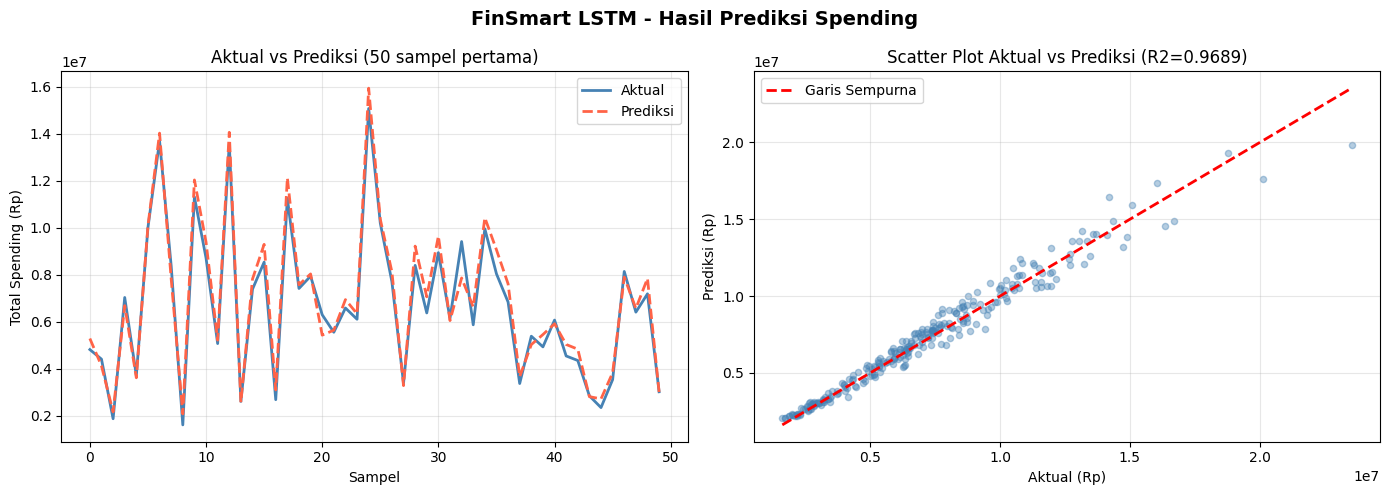

Grafik disimpan: lstm_prediction_result.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FinSmart LSTM - Hasil Prediksi Spending', fontsize=14, fontweight='bold')

n_show = min(50, len(y_test_actual))
axes[0].plot(y_test_actual[:n_show], label='Aktual',   color='steelblue', linewidth=2)
axes[0].plot(y_pred_actual[:n_show], label='Prediksi', color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('Aktual vs Prediksi (50 sampel pertama)')
axes[0].set_xlabel('Sampel')
axes[0].set_ylabel('Total Spending (Rp)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test_actual, y_pred_actual, alpha=0.4, color='steelblue', s=20)
min_val = min(y_test_actual.min(), y_pred_actual.min())
max_val = max(y_test_actual.max(), y_pred_actual.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Garis Sempurna')
axes[1].set_title(f'Scatter Plot Aktual vs Prediksi (R2={r2:.4f})')
axes[1].set_xlabel('Aktual (Rp)')
axes[1].set_ylabel('Prediksi (Rp)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_prediction_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: lstm_prediction_result.png')

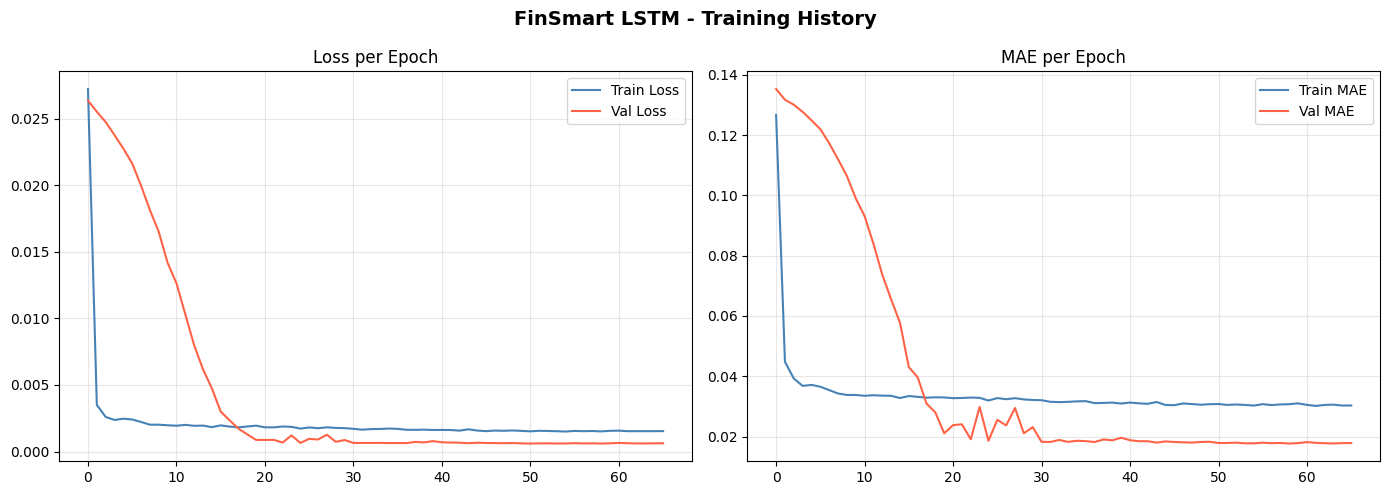

Grafik disimpan: lstm_training_history.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FinSmart LSTM - Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
axes[0].set_title('Loss per Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='tomato')
axes[1].set_title('MAE per Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: lstm_training_history.png')

## 9. Simpan Model dan Artifacts

In [14]:
LSTM_MODEL_PATH  = 'finsmart_lstm.keras'
SCALER_LSTM_PATH = 'scaler_lstm.pkl'
METADATA_PATH    = 'model_metadata_lstm.json'

best_lstm.save(LSTM_MODEL_PATH)
print(f'Model LSTM disimpan    : {LSTM_MODEL_PATH}')

with open(SCALER_LSTM_PATH, 'wb') as f:
    pickle.dump(scaler_lstm, f)
print(f'Scaler LSTM disimpan   : {SCALER_LSTM_PATH}')

metadata_lstm = {
    'model_name'     : 'FinSmart_LSTM_SpendingPrediction',
    'versi'          : '1.0.0',
    'task'           : 'Prediksi Total Pengeluaran Bulan Berikutnya',
    'arsitektur'     : 'LSTM 2 layer + Dense (TensorFlow Functional API)',
    'sequence_length': SEQUENCE_LENGTH,
    'n_features'     : len(FEATURES),
    'features'       : FEATURES,
    'target'         : TARGET,
    'dataset'        : 'dataset_spending_prediction.csv (200 user x 12 bulan)',
    'performa': {
        'MAE' : round(float(mae), 2),
        'RMSE': round(float(rmse), 2),
        'MAPE': round(float(mape), 2),
        'R2'  : round(float(r2), 4),
    },
    'endpoint_api': 'POST /predict-spending',
}

with open(METADATA_PATH, 'w') as f:
    json.dump(metadata_lstm, f, indent=2)
print(f'Metadata disimpan      : {METADATA_PATH}')
print()
print('Semua artifacts berhasil disimpan')

Model LSTM disimpan    : finsmart_lstm.keras
Scaler LSTM disimpan   : scaler_lstm.pkl
Metadata disimpan      : model_metadata_lstm.json

Semua artifacts berhasil disimpan


## 10. Kode Inference

In [15]:
class FinSmartLSTMInference:
    FEATURES = [
        'income', 'total_spending', 'savings',
        'Food & Dining', 'Transportation', 'Shopping',
        'Groceries', 'Bills & Utilities', 'Entertainment',
        'Health', 'Education', 'Others'
    ]
    TARGET = 'total_spending'

    def __init__(self, model_path, scaler_path):
        self.model = keras.models.load_model(model_path)
        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)
        self.seq_len = self.model.input_shape[1]
        print(f'FinSmartLSTMInference siap')
        print(f'Sequence length : {self.seq_len} bulan')
        print(f'Jumlah fitur    : {len(self.FEATURES)}')

    def preprocess(self, history: list) -> np.ndarray:
        if len(history) < self.seq_len:
            raise ValueError(f'Histori minimal {self.seq_len} bulan, diterima {len(history)} bulan.')
        history = history[-self.seq_len:]
        raw    = np.array([[h[f] for f in self.FEATURES] for h in history])
        scaled = self.scaler.transform(raw)
        return scaled.reshape(1, self.seq_len, len(self.FEATURES))

    def predict(self, history: list) -> dict:
        X        = self.preprocess(history)
        y_scaled = self.model.predict(X, verbose=0)[0][0]

        dummy = np.zeros((1, len(self.FEATURES)))
        target_idx = self.FEATURES.index(self.TARGET)
        dummy[0, target_idx] = y_scaled
        y_actual = self.scaler.inverse_transform(dummy)[0, target_idx]

        last_spending = history[-1]['total_spending']
        selisih       = y_actual - last_spending
        pct_change    = (selisih / last_spending) * 100 if last_spending > 0 else 0

        return {
            'prediksi_spending_bulan_depan': round(float(y_actual)),
            'spending_bulan_lalu'          : round(float(last_spending)),
            'selisih'                      : round(float(selisih)),
            'perubahan_pct'                : round(float(pct_change), 2),
            'trend'                        : 'naik' if selisih > 0 else 'turun',
            'insight': (
                f"Prediksi pengeluaran bulan depan Rp {y_actual:,.0f}. "
                f"{'Naik' if selisih > 0 else 'Turun'} {abs(pct_change):.1f}% dari bulan lalu."
            )
        }

lstm_inference = FinSmartLSTMInference(
    model_path=LSTM_MODEL_PATH,
    scaler_path=SCALER_LSTM_PATH
)

FinSmartLSTMInference siap
Sequence length : 3 bulan
Jumlah fitur    : 12


## 11. Uji Inference

In [16]:
histori_contoh = [
    {
        'income': 5000000, 'total_spending': 3200000, 'savings': 1800000,
        'Food & Dining': 800000, 'Transportation': 400000, 'Shopping': 500000,
        'Groceries': 300000, 'Bills & Utilities': 400000, 'Entertainment': 200000,
        'Health': 100000, 'Education': 200000, 'Others': 300000
    },
    {
        'income': 5000000, 'total_spending': 3500000, 'savings': 1500000,
        'Food & Dining': 900000, 'Transportation': 450000, 'Shopping': 600000,
        'Groceries': 350000, 'Bills & Utilities': 400000, 'Entertainment': 250000,
        'Health': 150000, 'Education': 200000, 'Others': 200000
    },
    {
        'income': 5000000, 'total_spending': 3800000, 'savings': 1200000,
        'Food & Dining': 1000000, 'Transportation': 500000, 'Shopping': 700000,
        'Groceries': 400000, 'Bills & Utilities': 400000, 'Entertainment': 300000,
        'Health': 100000, 'Education': 200000, 'Others': 200000
    },
]

hasil = lstm_inference.predict(histori_contoh)
print('=' * 55)
print('UJI INFERENCE LSTM SPENDING PREDICTION')
print('=' * 55)
print(f"Spending bulan lalu    : Rp {hasil['spending_bulan_lalu']:>12,}")
print(f"Prediksi bulan depan   : Rp {hasil['prediksi_spending_bulan_depan']:>12,}")
print(f"Selisih                : Rp {hasil['selisih']:>12,}")
print(f"Perubahan              : {hasil['perubahan_pct']}%")
print(f"Trend                  : {hasil['trend']}")
print(f"Insight                : {hasil['insight']}")
print('=' * 55)

UJI INFERENCE LSTM SPENDING PREDICTION
Spending bulan lalu    : Rp    3,800,000
Prediksi bulan depan   : Rp    3,743,316
Selisih                : Rp      -56,684
Perubahan              : -1.49%
Trend                  : turun
Insight                : Prediksi pengeluaran bulan depan Rp 3,743,316. Turun 1.5% dari bulan lalu.


## 12. Ringkasan

In [17]:
print('=' * 55)
print('RINGKASAN - FinSmart LSTM Spending Prediction')
print('CC26-PSU407 | Muhammad Syaiful')
print('=' * 55)
print('Model: LSTM 2 layer (TensorFlow Functional API)')
print(f'Sequence length : {SEQUENCE_LENGTH} bulan')
print(f'Jumlah fitur    : {len(FEATURES)}')
print()
print('Performa:')
print(f'  MAE  : Rp {mae:>12,.0f}')
print(f'  RMSE : Rp {rmse:>12,.0f}')
print(f'  MAPE : {mape:.2f}%')
print(f'  R2   : {r2:.4f}')
print()
print('File yang dihasilkan:')
files = [
    ('finsmart_lstm.keras',        'Model LSTM'),
    ('scaler_lstm.pkl',            'MinMaxScaler LSTM'),
    ('model_metadata_lstm.json',   'Metadata model LSTM'),
    ('training_log_lstm.json',     'Log training LSTM'),
    ('lstm_training_history.png',  'Grafik training'),
    ('lstm_prediction_result.png', 'Grafik prediksi'),
    ('spending_exploration.png',   'Grafik eksplorasi data'),
]
for fname, desc in files:
    status = '[Ada]' if os.path.exists(fname) else '[Akan dibuat saat run]'
    print(f'  {status} {fname:35s} : {desc}')
print('\n' + '=' * 55)

RINGKASAN - FinSmart LSTM Spending Prediction
CC26-PSU407 | Muhammad Syaiful
Model: LSTM 2 layer (TensorFlow Functional API)
Sequence length : 3 bulan
Jumlah fitur    : 12

Performa:
  MAE  : Rp      454,250
  RMSE : Rp      638,530
  MAPE : 6.37%
  R2   : 0.9689

File yang dihasilkan:
  [Ada] finsmart_lstm.keras                 : Model LSTM
  [Ada] scaler_lstm.pkl                     : MinMaxScaler LSTM
  [Ada] model_metadata_lstm.json            : Metadata model LSTM
  [Ada] training_log_lstm.json              : Log training LSTM
  [Ada] lstm_training_history.png           : Grafik training
  [Ada] lstm_prediction_result.png          : Grafik prediksi
  [Ada] spending_exploration.png            : Grafik eksplorasi data

